In [1]:
import sys
import os
import matplotlib.pyplot as plt
import cv2

import numpy as np

# Add the src directory to the path. TEMPORARY FIX
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from src.data_processing.dataset_loader import CoastData

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors


In [2]:
data_path_oblique_registered = os.path.abspath(os.path.join(os.getcwd(), "../../../data/SCLabels_oblique_registered_v1.0.0/"))
data_path_oblique = os.path.abspath(os.path.join(os.getcwd(), "../../../data/SCLabels_oblique_v1.0.0/"))
data_path_rectified = os.path.abspath(os.path.join(os.getcwd(), "../../../data/SCLabels_v1.0.0/"))

station_name = "arenaldentem"
data = {
    "oblique_registered": CoastData(data_path_oblique_registered, name=station_name),
    "oblique": CoastData(data_path_oblique, name=station_name),
    "rectified": CoastData(data_path_rectified, name=station_name)
}

index = 0  # Index of the image to load

# Olbique registered image
path_oblique_registered = data["oblique_registered"].get_images(get_mask=False)[index]
print(path_oblique_registered)
image_oblique_registered = cv2.imread(path_oblique_registered['image'])
image_oblique_registered = cv2.cvtColor(image_oblique_registered, cv2.COLOR_BGR2RGB)

# Oblique image and mask
path_oblique = data["oblique"].get_images(get_mask=True)[index]
print(path_oblique)
image_oblique = cv2.imread(path_oblique['image'])
image_oblique = cv2.cvtColor(image_oblique, cv2.COLOR_BGR2RGB)
mask_oblique = cv2.imread(path_oblique['mask'], cv2.IMREAD_GRAYSCALE)

# Rectified image and mask
path_rectified = data["rectified"].get_images(get_mask=True)[index]
print(path_rectified)
image_rectified = cv2.imread(path_rectified['image'])
image_rectified = cv2.cvtColor(image_rectified, cv2.COLOR_BGR2RGB)
mask_rectified = cv2.imread(path_rectified['mask'], cv2.IMREAD_GRAYSCALE)

CoastData: arenaldentem - 40 images
CoastData: arenaldentem - 40 images
CoastData: arenaldentem - 40 images
{'image': '/LOCALDATA/josep/Shoreline-extraction/data/SCLabels_oblique_registered_v1.0.0/images/1661756929.Mon.Aug.29_08_08_49.CET.2022.arenaldentem.image.jpg'}
{'image': '/LOCALDATA/josep/Shoreline-extraction/data/SCLabels_oblique_v1.0.0/images/1661756929.Mon.Aug.29_08_08_49.CET.2022.arenaldentem.image.jpg', 'mask': '/LOCALDATA/josep/Shoreline-extraction/data/SCLabels_oblique_v1.0.0/masks/1661756929.Mon.Aug.29_08_08_49.CET.2022.arenaldentem.mask.png'}
{'image': '/LOCALDATA/josep/Shoreline-extraction/data/SCLabels_v1.0.0/images/1661756929.Mon.Aug.29_08_08_49.CET.2022.arenaldentem.image.jpg', 'mask': '/LOCALDATA/josep/Shoreline-extraction/data/SCLabels_v1.0.0/masks/1661756929.Mon.Aug.29_08_08_49.CET.2022.arenaldentem.mask.png'}


In [3]:
# color_map_hex = {
#     'NoData': '#000000',       
#     'NotClassified': '#727272',
#     'Landwards': '#D2B48C',    
#     'Seawards': '#3434E7',     
#     'Shoreline': '#00FF00'     
# }

color_map_hex = {
    'NoData': '#000000',       
    'NotClassified': '#727272',
    'Landwards': '#8B4513',    
    'Seawards': '#0000FF',     
    'Shoreline': '#00FF00'     
}

classes_ordered = ['NoData', 'NotClassified', 'Landwards', 'Seawards', 'Shoreline']
colors_list = [color_map_hex[c] for c in classes_ordered]
cmap = mcolors.ListedColormap(colors_list)

bounds = [-1, 10, 50, 110, 200, 260]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

def add_border(ax, linewidth=0.2):
    ax.axis('on')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(linewidth)

def add_label(ax, text, x = 0.015, y = 0.92):
    ax.text(
        x, y, text, # Coordenades x, y (0 a 1)
        transform=ax.transAxes, # Important: relatiu als eixos, no píxels
        color='white', 
        fontsize=9, 
        fontweight='bold', 
        va='top', ha='left',
        bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='square,pad=0.2')

        # fontsize=9, color='white', weight='bold',
        #   bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2')
    )

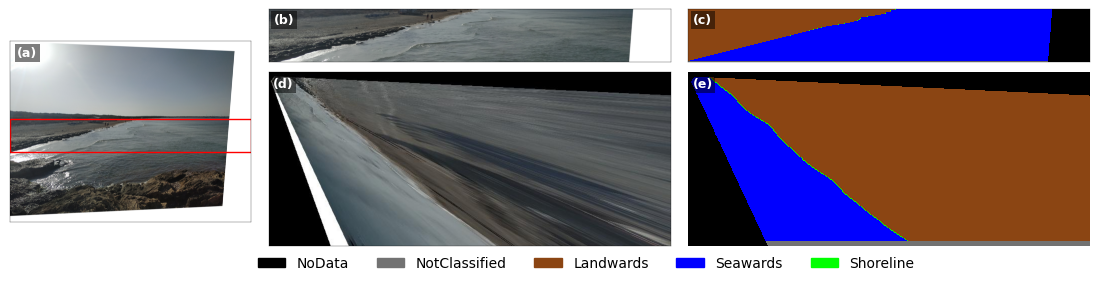

In [4]:
fig = plt.figure(figsize=(12, 2.8)) 
gs = fig.add_gridspec(2, 3, width_ratios=[0.6, 1, 1], height_ratios=[1, 3.5])

ax_context = fig.add_subplot(gs[:, 0])
ax_context.imshow(image_oblique_registered)
add_label(ax_context, "(a)", x=0.03, y=0.97)
add_border(ax_context)

# ROI
max_width = image_oblique_registered.shape[1]
rect = patches.Rectangle((5, 1285), max_width-10, 550, linewidth=1, edgecolor='red', facecolor='none')
ax_context.add_patch(rect)

ax_obl_img = fig.add_subplot(gs[0, 1])
ax_obl_img.imshow(image_oblique)
add_label(ax_obl_img, "(b)", x=0.013, y=0.92)
add_border(ax_obl_img)

ax_obl_mask = fig.add_subplot(gs[0, 2])
ax_obl_mask.imshow(mask_oblique, cmap=cmap, norm=norm, interpolation='nearest')
add_label(ax_obl_mask, "(c)", x=0.013, y=0.92)
add_border(ax_obl_mask)

ax_rect_img = fig.add_subplot(gs[1, 1])
ax_rect_img.imshow(image_rectified)
add_label(ax_rect_img, "(d)", x=0.011, y=0.97)
add_border(ax_rect_img) 

ax_rect_mask = fig.add_subplot(gs[1, 2])
ax_rect_mask.imshow(mask_rectified, cmap=cmap, norm=norm, interpolation='nearest')
add_label(ax_rect_mask, "(e)", x=0.011, y=0.97)
add_border(ax_rect_mask, linewidth=0.0)

legend_patches = [
    mpatches.Patch(color=color_map_hex[c], label=c) for c in classes_ordered
]

fig.legend(handles=legend_patches, 
           loc='lower center', 
           ncol=5,  
           bbox_to_anchor=(0.53, 0.02), 
           fontsize=10, 
           frameon=False)

plt.subplots_adjust(top=1, bottom=0.12, left=0.05, right=0.95, hspace=0.00, wspace=0.05)

plt.show()

dpi = 300
# fig.savefig(os.path.join("img", "example_image_and_mask_oblique_registered.png"), bbox_inches='tight', dpi=dpi)
# fig.savefig(os.path.join("pdf", "example_image_and_mask_oblique_registered.pdf"), bbox_inches='tight', dpi=dpi)
# fig.savefig(os.path.join("svg", "example_image_and_mask_oblique_registered.svg"), bbox_inches='tight', dpi=dpi)
# fig.savefig(os.path.join("tiff", "example_image_and_mask_oblique_registered.tiff"), bbox_inches='tight', dpi=600, pil_kwargs={"compression": "tiff_lzw"})

In [5]:
def add_hatched_strips(
    ax,
    img_shape,
    top=0,
    bottom=0,
    left=0,
    right=0,
    hatch='//',
    color='red',
    linewidth=0.5,
):
    h, w = img_shape[:2]

    # Fixar sistema de coordenades d'imatge
    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)

    if top > 0:
        ax.add_patch(
            patches.Rectangle(
                (0, 0), w, top,
                linewidth=linewidth,
                edgecolor=color,
                facecolor='none',
                hatch=hatch,
                zorder=10
            )
        )

    if bottom > 0:
        ax.add_patch(
            patches.Rectangle(
                (0, h - bottom), w, bottom,
                linewidth=linewidth,
                edgecolor=color,
                facecolor='none',
                hatch=hatch,
                zorder=10
            )
        )

    if left > 0:
        ax.add_patch(
            patches.Rectangle(
                (0, 0), left, h,
                linewidth=linewidth,
                edgecolor=color,
                facecolor='none',
                hatch=hatch,
                zorder=10
            )
        )

    if right > 0:
        ax.add_patch(
            patches.Rectangle(
                (w - right, 0), right, h,
                linewidth=linewidth,
                edgecolor=color,
                facecolor='none',
                hatch=hatch,
                zorder=10
            )
        )


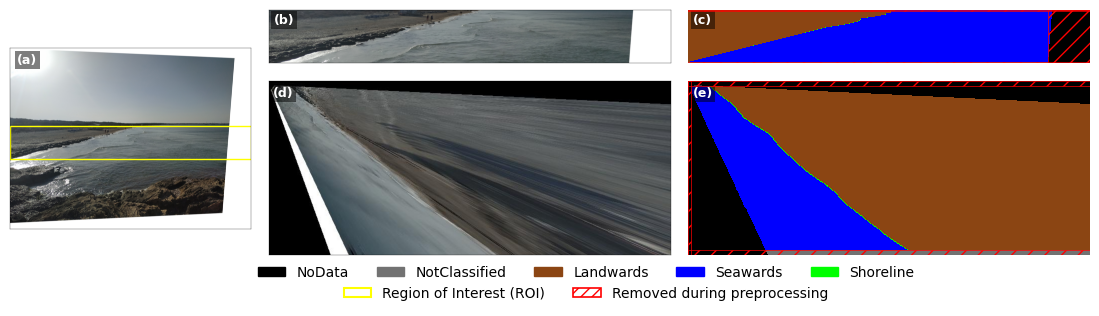

In [6]:
fig = plt.figure(figsize=(12, 3)) 
gs = fig.add_gridspec(2, 3, width_ratios=[0.6, 1, 1], height_ratios=[1, 3.5])

ax_context = fig.add_subplot(gs[:, 0])
ax_context.imshow(image_oblique_registered)
add_label(ax_context, "(a)", x=0.03, y=0.97)
add_border(ax_context)

# ROI
max_width = image_oblique_registered.shape[1]
rect = patches.Rectangle((5, 1285), max_width-10, 550, linewidth=1, edgecolor='yellow', facecolor='none')
ax_context.add_patch(rect)

ax_obl_img = fig.add_subplot(gs[0, 1])
ax_obl_img.imshow(image_oblique)
add_label(ax_obl_img, "(b)", x=0.013, y=0.92)
add_border(ax_obl_img)

ax_obl_mask = fig.add_subplot(gs[0, 2])
ax_obl_mask.imshow(mask_oblique, cmap=cmap, norm=norm, interpolation='nearest')

add_hatched_strips(
    ax_obl_mask,
    img_shape=mask_oblique.shape,
    top=10,
    left=0,
    right=415,
    bottom=10
)

add_label(ax_obl_mask, "(c)", x=0.013, y=0.92)
add_border(ax_obl_mask, linewidth=0.0)

ax_rect_img = fig.add_subplot(gs[1, 1])
ax_rect_img.imshow(image_rectified)
add_label(ax_rect_img, "(d)", x=0.011, y=0.97)
add_border(ax_rect_img) 

ax_rect_mask = fig.add_subplot(gs[1, 2])
ax_rect_mask.imshow(mask_rectified, cmap=cmap, norm=norm, interpolation='nearest')

add_hatched_strips(
    ax_rect_mask,
    img_shape=mask_rectified.shape,
    top=10,
    bottom=10,
    left=5,
    right=0
)

add_label(ax_rect_mask, "(e)", x=0.011, y=0.97)
add_border(ax_rect_mask, linewidth=0.0)


legend_patches = [
    mpatches.Patch(color=color_map_hex[c], label=c) for c in classes_ordered
]

# fig.legend(handles=legend_patches, 
#            loc='lower center', 
#            ncol=5,  
#            bbox_to_anchor=(0.53, 0.02), 
#            fontsize=10, 
#            frameon=False)

roi_patch = mpatches.Patch(
    facecolor='none',
    edgecolor='yellow',
    linewidth=1.5,
    label='Region of Interest (ROI)'
)

removed_patch = mpatches.Patch(
    facecolor='none',
    edgecolor='red',
    hatch='///',
    linewidth=1.2,
    label='Removed during preprocessing'
)

legend_patches_classes = [
    mpatches.Patch(color=color_map_hex[c], label=c)
    for c in classes_ordered
]

legend_patches_preproc = [
    roi_patch,
    removed_patch
]

all_handles = legend_patches_classes + legend_patches_preproc


fig.legend(
    handles=legend_patches_classes,
    loc='lower center',
    ncol=5,
    bbox_to_anchor=(0.53, 0.05),
    fontsize=10,
    frameon=False
)

fig.legend(
    handles=legend_patches_preproc,
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.53, -0.02),
    fontsize=10,
    frameon=False
)


plt.subplots_adjust(top=1, bottom=0.12, left=0.05, right=0.95, hspace=0.00, wspace=0.05)

plt.show()

dpi = 300
# fig.savefig(os.path.join("img", "example_image_and_mask_oblique_registered_preprocessed.png"), bbox_inches='tight', dpi=dpi)
# fig.savefig(os.path.join("pdf", "example_image_and_mask_oblique_registered_preprocessed.pdf"), bbox_inches='tight', dpi=dpi)
# fig.savefig(os.path.join("svg", "example_image_and_mask_oblique_registered_preprocessed.svg"), bbox_inches='tight', dpi=dpi)
# fig.savefig(os.path.join("tiff", "example_image_and_mask_oblique_registered_preprocessed.tiff"), bbox_inches='tight', dpi=600, pil_kwargs={"compression": "tiff_lzw"})

In [7]:
from src.data_processing.patchify import Patchify

CoastData: cadiz - 946 images
Coast: cadiz, Total size: 946
Image path: /LOCALDATA/josep/Shoreline-extraction/data/SCLabels_v1.0.0/images/1625291879.Sat.Jul.03_06_57_59.CET.2021.cadiz.image.jpg
Path: /LOCALDATA/josep/Shoreline-extraction/data/SCLabels_v1.0.0/images/1625291879.Sat.Jul.03_06_57_59.CET.2021.cadiz.image.jpg


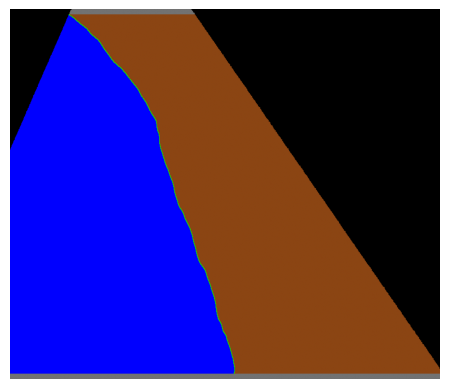

In [8]:
data_path = os.path.abspath(os.path.join(os.getcwd(), "../../../data/SCLabels_v1.0.0/"))

# Load the data, all the different stations
data = CoastData(data_path, name="cadiz") # arenaldentem

filtered_data = data.get_images() 

filtered_data = data.split_data()

# Get the first image and mask
image_path = filtered_data['train']['images'][0]
print("Image path:", image_path)
mask_path = filtered_data['train']['masks'][0]

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
# colored_mask = apply_custom_colormap(mask_img)

print("Path:", image_path)

# plt.imshow(image)
plt.imshow(mask_img, cmap=cmap, norm=norm)  # Overlay with some transparency
plt.axis('off')
plt.show()

Rows: 4
Cols: 6


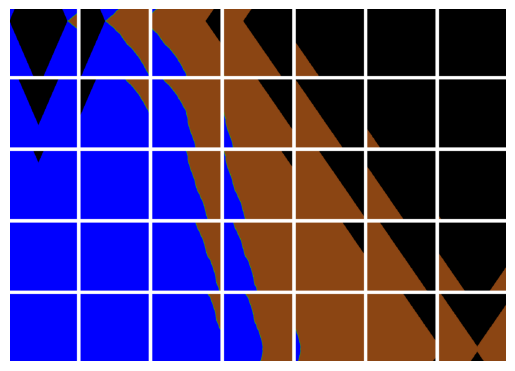

In [19]:
out_patchify = Patchify(patch_size=(256, 256), stride=(128, 128))

result = out_patchify.extract_patches(image_path=image_path, mask_path=mask_path, skip_background=False, skip_no_shoreline=False, padding_mode='reflect')
cropped_mask = mask_img[10:-10, :]
cropped_image = image[10:-10, :]

# temporal file
import tempfile
with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as temp_image_file:
    temp_image_path = temp_image_file.name
    cv2.imwrite(temp_image_path, cv2.cvtColor(cropped_image, cv2.COLOR_RGB2BGR))

    with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as temp_mask_file:
        temp_mask_path = temp_mask_file.name
        cv2.imwrite(temp_mask_path, cropped_mask)
    
        result = out_patchify.extract_patches(image_path=temp_image_path, mask_path=temp_mask_path, skip_background=False, skip_no_shoreline=False, padding_mode='reflect')

from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import matplotlib.pyplot as plt
import numpy as np
import cv2

rows = max(patch['row'] for patch in result['patches'])
cols = max(patch['col'] for patch in result['patches'])
print("Rows:", rows)
print("Cols:", cols)

fig, axes = plt.subplots(rows + 1, cols + 1, figsize=(3*(cols + 1), 3 * (rows + 1)))
axes = axes.flatten()

for i, patch in enumerate(result['patches']):
    ax = axes[patch['row'] * (cols + 1) + patch['col']]
    patch['image'] = cv2.cvtColor(patch['image'], cv2.COLOR_BGR2RGB)
    aux_mask = patch['mask']
    ax.imshow(aux_mask, cmap=cmap, norm=norm, interpolation='nearest')
    ax.axis('off')

plt.tight_layout()
# plt.show()

canvas = FigureCanvas(fig)
canvas.draw()
img = np.frombuffer(canvas.buffer_rgba(), dtype='uint8')
img = img.reshape(canvas.get_width_height()[::-1] + (4,))
img = img[:, :, :3]

patchify_mask = np.array(img, dtype=np.uint8)
patchify_mask = patchify_mask[20:-20, 20:-20]

plt.close(fig)

plt.imshow(patchify_mask)
plt.axis("off")
plt.show()


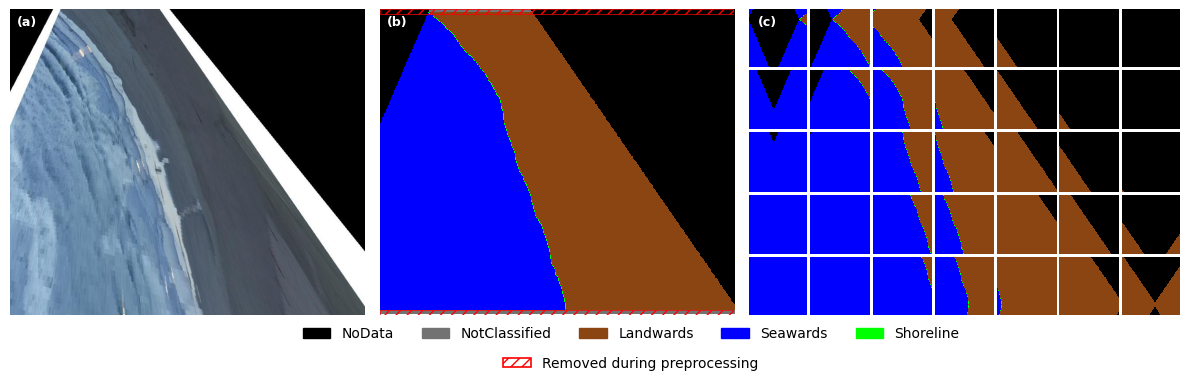

In [42]:
import matplotlib.patches as mpatches

# Create the figure
fig, axes = plt.subplots(1, 3, figsize=(12, 4.25), width_ratios=[1, 1, 1.215])  # Slightly wider

# Top row: RGB image
axes[0].imshow(image)
add_label(axes[0], "(a)", x=0.02, y=0.98)
axes[0].axis('off')

# Bottom row: mask
axes[1].imshow(mask_img, cmap=cmap, norm=norm, interpolation='nearest')
add_label(axes[1], "(b)", x=0.02, y=0.98)
add_hatched_strips(
    axes[1], 
    mask_img.shape, 
    top=10, bottom=10, left=0, right=0, 
    color='red', hatch='///'
)
axes[1].axis('off')


axes[2].imshow(patchify_mask, cmap=cmap, norm=norm, interpolation='nearest')
add_label(axes[2], "(c)", x=0.02, y=0.98)
axes[2].axis('off')


removed_patch = mpatches.Patch(
    facecolor='none',
    edgecolor='red',
    hatch='///',
    linewidth=1.2,
    label='Removed during preprocessing'
)

legend_patches_classes = [
    mpatches.Patch(color=color_map_hex[c], label=c)
    for c in classes_ordered
]

legend_patches_preproc = [
    removed_patch
]

all_handles = legend_patches_classes + legend_patches_preproc


fig.legend(
    handles=legend_patches_classes,
    loc='lower center',
    ncol=5,
    bbox_to_anchor=(0.53, 0.05),
    fontsize=10,
    frameon=False
)

fig.legend(
    handles=legend_patches_preproc,
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.53, -0.02),
    fontsize=10,
    frameon=False
)


plt.subplots_adjust(top=1, bottom=0.0, left=0.05, right=0.95, hspace=0.00, wspace=0.05)

plt.tight_layout()
plt.show()
dpi = 300
fig.savefig(os.path.join("img", "example_image_and_mask_preprocessed_patchify.png"), bbox_inches='tight', dpi=dpi)
fig.savefig(os.path.join("pdf", "example_image_and_mask_preprocessed_patchify.pdf"), bbox_inches='tight', dpi=dpi)
fig.savefig(os.path.join("svg", "example_image_and_mask_preprocessed_patchify.svg"), bbox_inches='tight', dpi=dpi)
fig.savefig(os.path.join("tiff", "example_image_and_mask_preprocessed_patchify.tiff"), bbox_inches='tight', dpi=600, pil_kwargs={"compression": "tiff_lzw"})
